## Application 11: Aortic Stenosis Detection Using Seismocardiogram and Gyrocardiogram

**Authors:** Jakob Beber, Daniël Schoeren, Janita Collin

---

## Introduction

Primary objective of this project was to create a machine learning pipeline to classify patients as either having Aortic Stenosis (AO) or not (No AO).

In this project we selected to use the following two classifiers: Decision tree, Gradient Boosting. Because of strugling performance from decision tree we later implemented random forest to showcase the differences between two classifiers.

---

## Dataset and preprocessing

We got a short time series recordings consisting of 6-channel sensor data: Seismocardiography (SCG: X, Y, Z) and Gyrocardiography (GCG: X, Y, Z), sampled at 256 Hz. The dataset was split into:
- Train Set: 4168 samples (1590 AO, 2578 No AO)
- Test Set: 536 samples (248 AO, 288 No AO)

Raw SCG and GCG signals contain noise and drift that do not contribute to correct assessment. To isolate the relevant heart movement frequencies, we preprocessed all 6 channels using a **butterworth bandpass filter** with a frequency band of 0.5 Hz to 40.0 Hz. 

---

## Extraced features

Features per channel included: Absolute Energy, Root Mean Square (RMS), 20 PSD Power Bands, Mean, Median, Standard Deviation, and Kurtosis. We also added Total SCG Energy and Total GCG Energy.

The most we could change/empiricaly test was number of PSD power bands we wanted to split to. We started with only 3, but it quickly turned out that the more band we created, the better the results got at the classifiers.

---

## Models, Observations, and Final Results


We chose a Decision tree classifier for:
*   **Explainability:** DT use easily interpretable *if-statements*, making clinical reasoning transparent
*   **Feature handling:** it should handle the large (158) number of features we extracted
*   **Novelty:** it allowed us to try a different methodological approach compared to previous application.

Initial observations via 5-Fold cross validation showed that while the baseline learned general patterns, it struggled significantly with a high rate of false negatives.

To improve predictive performance, we implemented two other classifiers **Random Forest** and **Gradient Boosting**. We evaluated all models on the test set. As shown in the table below, while overall performance improved with the ensemble models (Gradient boosting achieving perfect precision (1.00)). It is worth nothing the highest F1 score all models still got relatively low recall. 

| Model | Recall | F1-Score |
| :--- | :---: | :---: |
| **Decision Tree** | 0.5645 | 0.6364 |
| **Random Forest** | **0.6290** | 0.7107 |
| **Gradient Boosting** *(Best)* | 0.5927 | **0.7443** |

---

## Conclusion and Future Possibilities

Gradient boosting was our best performing model. Its perfect precision indicates that when the model predicts Aortic stenosis(AS), it is 100% correct. However, the recall remains low across all tested algorithms (~0.56–0.63), meaning the models act conservatively and still miss several true positive cases. We think this shows lack of extracted features or just the nature of classifying a hard problem.

To improve scores, we reviewed relevant literature and find two options:
1. extracting more features (similar to our approach in application 1),
2. implementing a convolutional neural network (CNN) model [2].

To address the low recall, future work could implement any of the options from our literature review: implementing the CNN model [2] to capture complex spatial temporal features, or further extract features to make positive AO cases more distinctly recognizable.

---

### References
**[1]** Arash Shokouhmand, Nicole D. Aranoff, Elissa Driggin, Philip Green & Negar Tavassolian. *"Efficient detection of aortic stenosis using morphological characteristics of cardiomechanical signals and heart rate variability parameters."*
**[2]** Ismail Elnaggar, Tero Hurnanen, Olli Lahdenoja, Antti Airola, Matti Kaisti, Tuija Vasankari, Jouni Pykäri, Mikko Savontaus, Tero Koivisto. *"Detecting Aortic Stenosis using Seismocardiography and Gryocardiography combined with Convolutional Neural Networks."* (University of Turku).

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

### 1. Load SCG/GCG Data

Num. of AO stenosis -Train: 1590
Num. of No AO stenosis -Train: 2578
Num. of AO stenosis - Test: 248
Num. of No AO stenosis -Test: 288


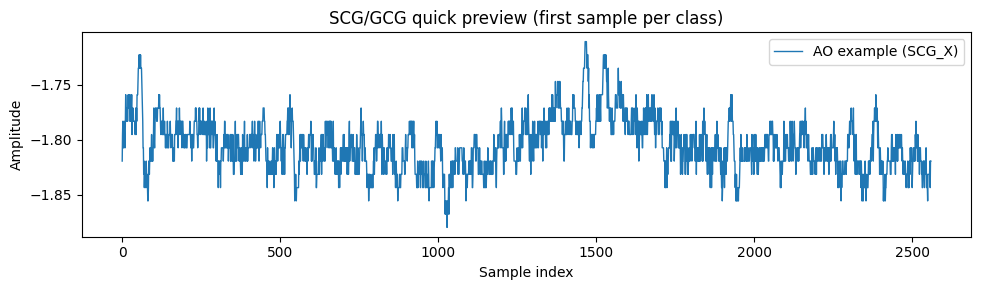

In [2]:
# where is data stored 
data_path = Path("Data")

def load_scg_csv_dataset(root_dir: Path, split: str = "Train"):
    """
    Load SCG/GCG data from CSV files as class subfolders
    """
    # define where to find csv files
    pos_files_path = sorted((root_dir / split / "Aortic_Stenosis").rglob("*.csv"))
    neg_files_path = sorted((root_dir / split / "No_Aortic_Stenosis").rglob("*.csv"))

    # this will be output/returned
    pos_signals, neg_signals = [], []

    # assuming shape is (N_samples, 6) for 6 channels (SCG X, Y, Z, GCG X, Y, Z)
    for csv_path in pos_files_path:
        # skiprows=1 if header exists
        signal = np.loadtxt(csv_path, delimiter=",", skiprows=1, dtype=float)
        pos_signals.append(np.asarray(signal, dtype=float))

    for csv_path in neg_files_path:
        signal = np.loadtxt(csv_path, delimiter=",", skiprows=1, dtype=float)
        neg_signals.append(np.asarray(signal, dtype=float))

    return pos_signals, pos_files_path, neg_signals, neg_files_path

# Train set
train_pos_signals, _, train_neg_signals, _ = load_scg_csv_dataset(data_path, split="Train")
X_train_raw = train_pos_signals + train_neg_signals
y_train = (["Aortic_Stenosis"] * len(train_pos_signals)) + (["No_Aortic_Stenosis"] * len(train_neg_signals))

#Test set
test_pos_signals, _, test_neg_signals, _ = load_scg_csv_dataset(data_path, split="Test")
X_test_raw = test_pos_signals + test_neg_signals
y_test = (["Aortic_Stenosis"] * len(test_pos_signals)) + (["No_Aortic_Stenosis"] * len(test_neg_signals))

print(f"Num. of AO stenosis -Train: {len(train_pos_signals)}")
print(f"Num. of No AO stenosis -Train: {len(train_neg_signals)}")
print(f"Num. of AO stenosis - Test: {len(test_pos_signals)}")
print(f"Num. of No AO stenosis -Test: {len(test_neg_signals)}")

# visual check of loaded signal
# comment out if you dont want visuals 
plt.figure(figsize=(10, 3))
plt.plot(train_pos_signals[0][:, 0], label="AO example (SCG_X)", linewidth=1)
#plt.plot(train_neg_signals[0][:, 0], label="No AO example (SCG_X)", linewidth=1, alpha=0.8)
plt.title("SCG/GCG quick preview (first sample per class)")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

#### 1. Pre processing step

Process train sig: 4168
Processed test sig: 536


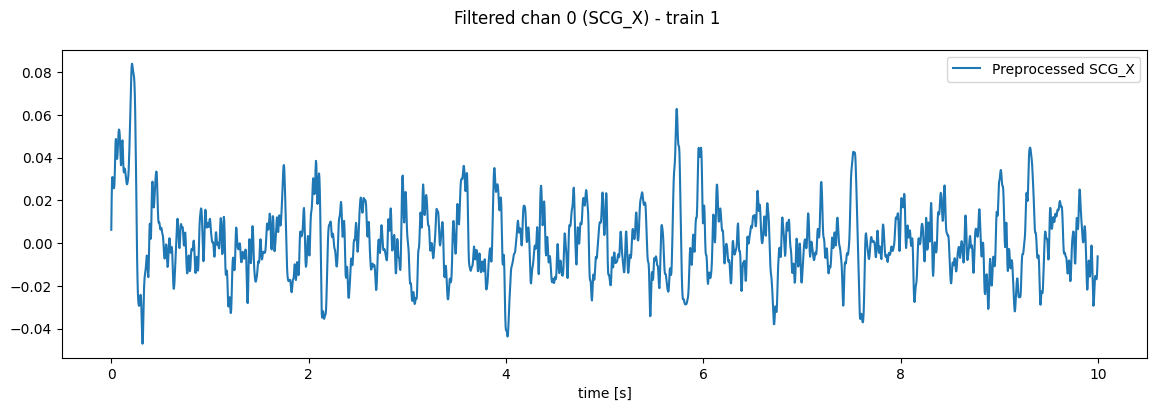

In [3]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# ============ Helper functions ==============

def butter_filter(chan: np.ndarray, fs: int, N: int = 3, lf: float = 0.5, hf: float = 40):
    """
    Apply a Butterworth bp filter.
    """
    b, a = butter(N, [lf, hf], fs=fs, btype='bandpass')
    return filtfilt(b, a, chan)

def preprocess_pipeline(sig: np.ndarray, fs: int = 256):
    """
    1. function performs bp filtering
    2. standardization is done after feature extraction, with sklearn
    """
    # assuming sig shape is (N_samples, 6 channels)
    # chan: SCG_X, SCG_Y, SCG_Z, GCG_X, GCG_Y, GCG_Z
    filtered_sig = np.zeros_like(sig)
    
    # 0.5 to 40 Hz
    for i in range(sig.shape[1]):
        filtered_sig[:, i] = butter_filter(sig[:, i], fs, lf=0.5, hf=40)

    return filtered_sig

fs_orig = 256

sig_train_pre = []
for sig in X_train_raw:
    clean_processed = preprocess_pipeline(sig, fs=fs_orig)
    sig_train_pre.append(clean_processed)
    
sig_test_pre = []
for sig in X_test_raw:
    clean_processed = preprocess_pipeline(sig, fs=fs_orig)
    sig_test_pre.append(clean_processed)

print(f"Process train sig: {len(sig_train_pre)}")
print(f"Processed test sig: {len(sig_test_pre)}")

if len(sig_train_pre) > 0:
    # visualize processed signals
    fig, ax = plt.subplots(1,1, figsize=(14, 4))
    fig.suptitle('Filtered chan 0 (SCG_X) - train 1')
    # Create simple time axis
    time_ax = np.arange(len(sig_train_pre[0])) / fs_orig
    ax.plot(time_ax, sig_train_pre[0][:, 0], label='Preprocessed SCG_X')
    ax.set_xlabel('time [s]')
    ax.legend()
    plt.show()

### Step 2:

**instruction:**

- Feature Extraction: Absolute energy, RMS, Power bands (PSD), Total SCG/GCG energy, Statistical features (mean, std, median, kurtosis).

In [4]:
from scipy.stats import kurtosis
from scipy.signal import welch

def extract_features(sig: np.ndarray, fs: int = 256):
    """
    From the signals, extract time-domain and frequency-domain features:
    - absolute energy,
    - RMS value,
    - power bands (from PSD of the signal),
    - total SCG/GCG energy (adding the energies from each SCG or GCG channel together)
    - various statistical features, such as mean, median, standard deviation, and kurtosis
    """
    features = []
    
    # stats for each channel
    for i in range(6):
        chan = sig[:, i]
        
        # abs energy
        abs_energy = np.sum(chan**2)
        features.append(abs_energy)
        
        # RMS
        rms = np.sqrt(np.mean(chan**2))
        features.append(rms)
        
        # power bands from PSD (0.5-10Hz, 10-20Hz, 20-40Hz)
        # this is one of the things we can adjust and regulate how much features do we extract out of the PSD
        # we started with 3 bands, increased to 5 and found better results
        # with 20 bands its quite a lot of features, which hurt a bit of DT pref., however grad boosting provides best performance

        freqs, psd = welch(chan, fs, nperseg=fs*2)
        num_bands = 20
        edges = np.linspace(0.5, 40.0, (num_bands+1))  # 20 bands between 0.5 and 40 Hz
        bands = []
        for b in range(len(edges) - 1):
            if b == len(edges) - 2:
                band_power = np.sum(psd[(freqs >= edges[b]) & (freqs <= edges[b+1])])
            else:
                band_power = np.sum(psd[(freqs >= edges[b]) & (freqs < edges[b+1])])
                bands.append(band_power)
        features.extend(bands)
        
        # statistical
        features.append(np.mean(chan))
        features.append(np.median(chan))
        features.append(np.std(chan))
        features.append(kurtosis(chan))
        
    # total SCG/GCG energy
    # SCG energy: sum(X^2 + Y^2 + Z^2)
    scg_total_energy = np.sum(sig[:, 0]**2 + sig[:, 1]**2 + sig[:, 2]**2)
    # GCG energy: sum(X^2 + Y^2 + Z^2)
    gcg_total_energy = np.sum(sig[:, 3]**2 + sig[:, 4]**2 + sig[:, 5]**2)
    
    features.extend([scg_total_energy, gcg_total_energy])
    
    return np.array(features)

X_train_feat = []
for sig in sig_train_pre:
    X_train_feat.append(extract_features(sig, fs=256))
    
X_test_feat = []
for sig in sig_test_pre:
    X_test_feat.append(extract_features(sig, fs=256))

X_train_feat = np.array(X_train_feat)
X_test_feat = np.array(X_test_feat)

print("Feature extraction done")
print(f"X_train feat shape: {X_train_feat.shape}")
print(f"X_test feat shape: {X_test_feat.shape}")

Feature extraction done
X_train feat shape: (4168, 152)
X_test feat shape: (536, 152)


### Step 3 and 4: Standardize and Machine Learning

**Instruction:**

- Standardize data using `StandardScaler` (fit on train, transform on both)
- Initialize and train **two** supervised ML models

In [5]:
from sklearn.preprocessing import StandardScaler
# ref: https://www.geeksforgeeks.org/machine-learning/standardscaler-minmaxscaler-and-robustscaler-techniques-ml/


# 1 standardization (fit on train, transform on both)
scaler = StandardScaler()

if len(X_train_feat) > 0:
    X_train_scaled = scaler.fit_transform(X_train_feat)
    X_test_scaled = scaler.transform(X_test_feat)
    print('Successful standardization')
else:
    print('Error in standardization')



Successful standardization


In [6]:
# prepare inputs/outputs
X_train = X_train_scaled
X_test = X_test_scaled

y_train_arr = np.array(y_train)
y_test_arr = np.array(y_test)


# setup K-Fold 
from sklearn.model_selection import StratifiedKFold, cross_val_score
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [7]:
from sklearn.tree import DecisionTreeClassifier

# init DT
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')

# 1. evaluate using cross validation
cv_scores = cross_val_score(dt_clf, X_train, y_train_arr, cv=kfold, scoring='accuracy')

print("Stratified k-fold cross validation (train set)")
print(f"Fold acc: {cv_scores}")
print(f"Mean cv accuracy: {cv_scores.mean():.4f} (std: +/- {cv_scores.std():.4f})\n")

# 2. train on the entire training set & predict on the test set
dt_clf.fit(X_train, y_train_arr)
y_pred_dt = dt_clf.predict(X_test)

Stratified k-fold cross validation (train set)
Fold acc: [0.9028777  0.87170264 0.86211031 0.89555822 0.90036014]
Mean cv accuracy: 0.8865 (std: +/- 0.0165)



In [8]:

# RF should reduce overfitting compared to a decision tree

from sklearn.ensemble import RandomForestClassifier
# init RF
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')

# 1. evaluate using cross validation
cv_scores = cross_val_score(rf_clf, X_train, y_train_arr, cv=kfold, scoring='accuracy')

print("Stratified k-fold cross validation (train set)")
print(f"Fold acc: {cv_scores}")
print(f"Mean cv accuracy: {cv_scores.mean():.4f} (std: +/- {cv_scores.std():.4f})\n")

# 2. train on the entire training set & predict on the test set
rf_clf.fit(X_train, y_train_arr)
y_pred_rf = rf_clf.predict(X_test)


Stratified k-fold cross validation (train set)
Fold acc: [0.94244604 0.91127098 0.92565947 0.91716687 0.92196879]
Mean cv accuracy: 0.9237 (std: +/- 0.0105)



In [9]:
from sklearn.ensemble import GradientBoostingClassifier

# init the Gradient Boosting Classifier
# max_depth=3 - good default
gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)

# 1. evaluate using cross validation
cv_scores = cross_val_score(gb_clf, X_train, y_train_arr, cv=kfold, scoring='accuracy')

print("Stratified k-fold cross validation (train set)")
print(f"Fold acc: {cv_scores}")
print(f"Mean cv accuracy: {cv_scores.mean():.4f} (Std: +/- {cv_scores.std():.4f})\n")

# 2. train on the entire training set & predict on the test set
gb_clf.fit(X_train, y_train_arr)
y_pred_gb = gb_clf.predict(X_test)


Stratified k-fold cross validation (train set)
Fold acc: [0.97482014 0.95683453 0.97601918 0.97118848 0.96518607]
Mean cv accuracy: 0.9688 (Std: +/- 0.0071)



# Step 5

Compare the two classifiers by evaluating the results using the test set.

- Obtain the confusion matrix, accuracy, precision, recall, and F1-score. These can be calculated from the predicted and true values.

Test set evaluations of the classifiers

---------- Decision Tree ----------
Accuracy:    0.7015
Precision:   0.7292
Recall:      0.5645
F1-Score:    0.6364


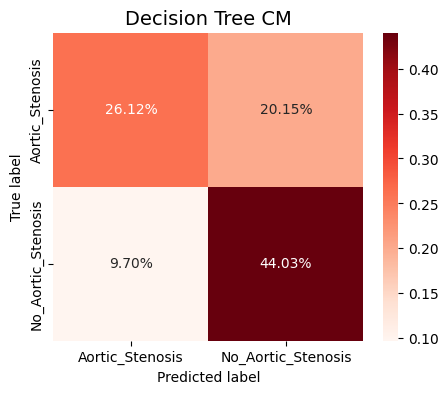



---------- Random Forest ----------
Accuracy:    0.7631
Precision:   0.8168
Recall:      0.6290
F1-Score:    0.7107


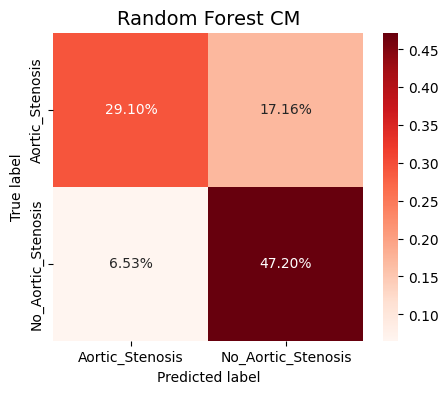



---------- Gradient Boosting ----------
Accuracy:    0.8116
Precision:   1.0000
Recall:      0.5927
F1-Score:    0.7443


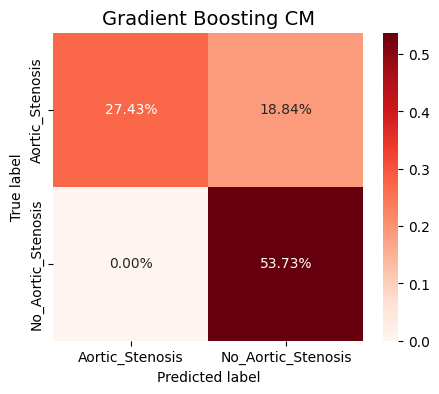

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_and_print_metrics(classifier_name, y_true, y_pred, pos_label="Aortic_Stenosis"):
    """
    Calculates and prints the accuracy, precision, recall, F1-score, and plots the confusion matrix
    for a given set of true and predicted labels.
    """
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=pos_label)
    rec = recall_score(y_true, y_pred, pos_label=pos_label)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label)
    cm = confusion_matrix(y_true, y_pred)
    
    # print results / metrics
    print(f"---------- {classifier_name} ----------")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Precision:   {prec:.4f}")
    print(f"Recall:      {rec:.4f}")
    print(f"F1-Score:    {f1:.4f}")
    

    # plot cm
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm / np.sum(cm), annot=True, fmt='.2%', cmap='Reds', 
                xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.title(f'{classifier_name} CM', fontsize=14)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()
    print("\n")
    

print("Test set evaluations of the classifiers\n")

# DT
evaluate_and_print_metrics("Decision Tree", y_test_arr, y_pred_dt)
# RF
evaluate_and_print_metrics("Random Forest", y_test_arr, y_pred_rf)
# grad boost
evaluate_and_print_metrics("Gradient Boosting", y_test_arr, y_pred_gb)


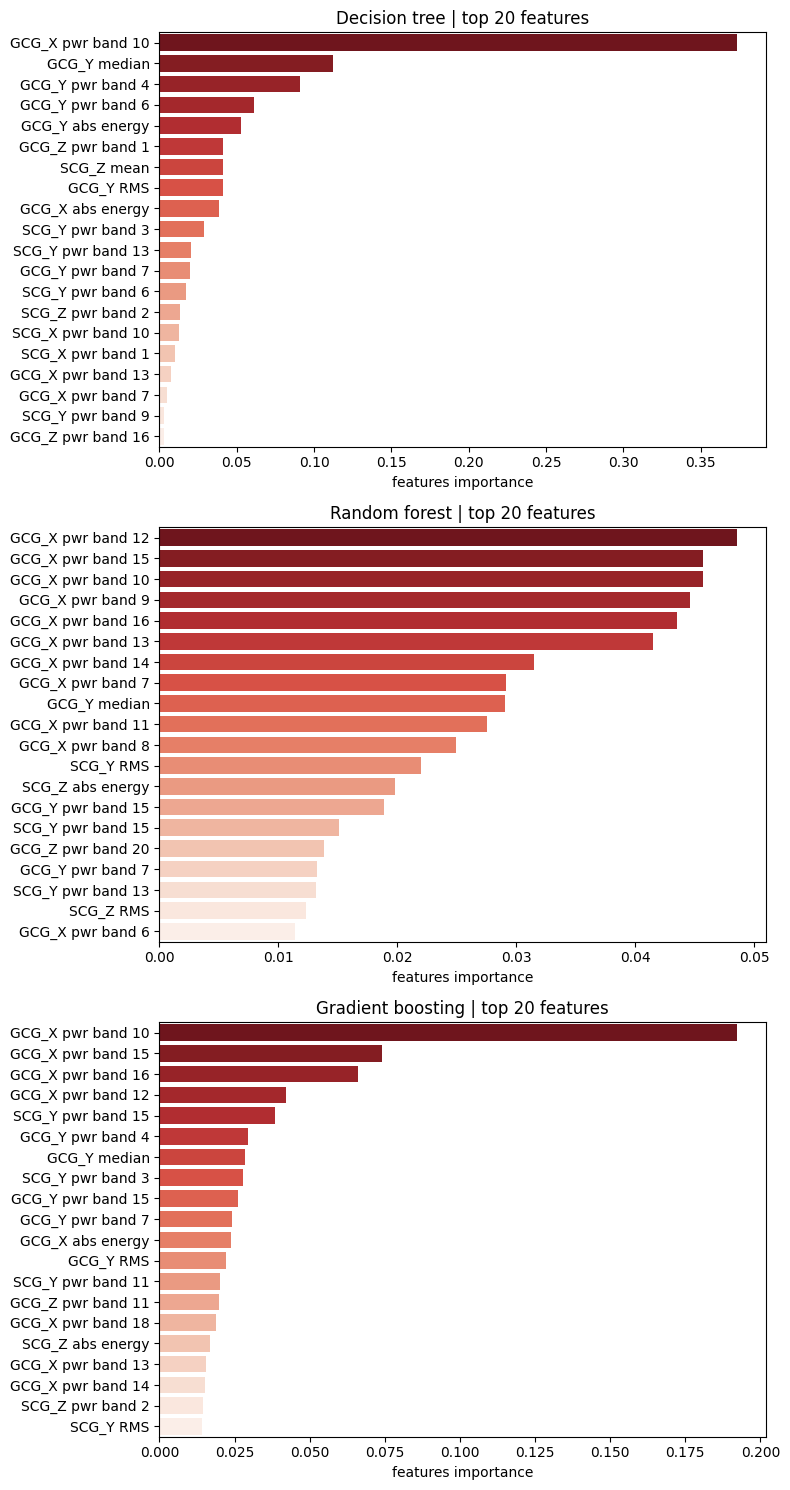

In [19]:
# features importance for each classifier

# define chan
chan = ["SCG_X", "SCG_Y", "SCG_Z", "GCG_X", "GCG_Y", "GCG_Z"]
# posible stats from each chan
stats = ["abs energy", "RMS"] + [f"pwr band {i+1}" for i in range(20)] + ["mean", "median", "std", "Kurtosis"]

# iterate through feats
feature_names = []
for ch in chan:
    for stat in stats:
        feature_names.append(f"{ch} {stat}")
feature_names.extend(["Total SCG energy", "Total GCG energy"])
feature_names = np.array(feature_names)


models = [
    ("Decision tree", dt_clf),
    ("Random forest", rf_clf),
    ("Gradient boosting", gb_clf)
]


# plot the graphs
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
for ax, (name, model) in zip(axes, models):
    importances = model.feature_importances_
    
    # sort importances and get top 20
    top_indices = np.argsort(importances)[::-1][:20]
    top_importances = importances[top_indices]
    top_features = feature_names[top_indices]
    
    sns.barplot(x=top_importances, y=top_features, hue=top_features, ax=ax, palette='Reds_r', legend=False)
    ax.set_title(f"{name} | top 20 features")
    ax.set_xlabel("features importance")

plt.tight_layout()
plt.show()